# IQR 이상치 제거 유무 A/B — 실측치 데이터

`Cement_code/chronos_quality/01_iqr_outlier_removal/`의 재현판. 데이터는 **운전&품질데이터_실측치.xlsx**, context_length는 2026-09-06 스윕 최적값 (**blaine 512 / residue 256**).

**IQR 제거**: `clean()`의 물리 규칙을 통과한 뒤, 호기별·컬럼별 Tukey 1.5×IQR 펜스 밖 값을 NaN 처리 (`build_dataset.iqr_cols()` = `RP_proc_time` 제외한 전 raw feature + blaine/residue). 실측치 데이터에서 총 **115,210개** 값이 NaN 처리됨 (최다: feed_slag 29k — SLAG 미투입 배치가 통계적으로 이상치로 잡힘).

**설계**: 4 모델 = {blaine, residue} × {withiqr 학습, withoutiqr 학습}, full fine-tune / predlen 4 / 1000 steps / lr 1e-6 / batch 64. 각 모델을 **두 테스트셋 모두**에서 backtest:
- `evalon_raw` = without_iqr 테스트셋 (극단값 포함, 실측 그대로) = **배포 현실, 주지표**
- `evalon_clean` = with_iqr 테스트셋 (IQR로 극단값 제거된 정상운전 구간)

같은 테스트셋에서 두 모델을 평가해야 naive baseline / skill-score 분모가 동일 → 공정 비교.

정규화 skill-score < 1 이면 naive(직전값 반복) baseline보다 낫다는 뜻. GPU 안 씀.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

CTX = {'blaine': 512, 'residue': 256}
TRAINVARS = ['withoutiqr', 'withiqr']
EVALVARS = ['raw', 'clean']
TRAIN_LABEL = {'withoutiqr': 'IQR 미적용', 'withiqr': 'IQR 적용'}
COLOR = {'withoutiqr': 'tab:blue', 'withiqr': 'tab:orange'}


## 1. 결과 로딩 (4 모델 × 2 테스트셋 = 8 backtest)

In [2]:
res = {}
missing = []
for t in cfg.TARGET_COLS:
    ctx = CTX[t]
    for tv in TRAINVARS:
        for ev in EVALVARS:
            p = ROOT / 'eval' / f'backtest_{t}_ctx{ctx}_{tv}_evalon_{ev}.csv'
            if p.exists():
                res[(t, tv, ev)] = pd.read_csv(p, parse_dates=['timestamp'])
            else:
                missing.append(p.name)
print('missing:', missing or 'NONE')
print('loaded :', len(res), '/ 8')


missing: NONE
loaded : 8 / 8


## 2. 요약표

행 = (타깃, 학습 데이터, 평가 테스트셋). `evalon_raw`가 주지표. 같은 (타깃, 평가셋) 안에서 `withoutiqr` vs `withiqr` 를 비교하면 됨.

In [3]:
rows = []
for t in cfg.TARGET_COLS:
    for ev in EVALVARS:
        for tv in TRAINVARS:
            df = res.get((t, tv, ev))
            if df is None:
                continue
            m = compute_metrics(df, cfg.SPEC_RANGES[t])
            nmae = float(np.abs(df['actual'] - df['naive_pred']).mean())
            rows.append({'target': t, 'eval_set': ev, 'train_data': tv, 'n': len(df),
                         'MAE': round(m['MAE'], 4), 'R2': round(m['R2'], 4),
                         'spec%': round(m['spec_accuracy'] * 100, 2),
                         'cov80%': round(m['interval_coverage'] * 100, 2),
                         'macro_MAE': round(macro_average_mae(df), 4),
                         'skill': round(normalized_skill_score(df), 4),
                         'naive_MAE': round(nmae, 4)})
summary = pd.DataFrame(rows).set_index(['target', 'eval_set', 'train_data'])
summary


n      MAE      R2  spec%  cov80%  macro_MAE  \
target  eval_set train_data                                                   
blaine  raw      withoutiqr  851  69.6349  0.4737  70.15   66.16    69.5736   
                 withiqr     851  69.9631  0.4663  69.45   67.80    69.9172   
        clean    withoutiqr  830  69.2609  0.4411  69.88   65.42    69.3696   
                 withiqr     830  69.7572  0.4332  70.00   66.99    69.8704   
residue raw      withoutiqr  856   0.4585  0.7701  83.06   69.74     0.4581   
                 withiqr     856   0.4587  0.7695  82.36   68.34     0.4584   
        clean    withoutiqr  716   0.4145  0.7744  77.79   69.55     0.4137   
                 withiqr     716   0.4160  0.7740  76.82   69.13     0.4148   

                              skill  naive_MAE  
target  eval_set train_data                     
blaine  raw      withoutiqr  0.8319    83.7673  
                 withiqr     0.8361    83.7673  
        clean    withoutiqr  0.8652    80.2530  
                 withiqr     0.8715    80.2530  
residue raw      withoutiqr  0.8086     0.5685  
                 withiqr     0.8093     0.5685  
        clean    withoutiqr  0.8723     0.4765  
                 withiqr     0.8749     0.4765

## 3. Δ (IQR 적용 − IQR 미적용), 테스트셋별

음수 = IQR 적용이 나쁨 (MAE/skill 기준).

In [4]:
for ev in EVALVARS:
    print(f'=== evalon_{ev} ===')
    for t in cfg.TARGET_COLS:
        a = res.get((t, 'withoutiqr', ev)); b = res.get((t, 'withiqr', ev))
        if a is None or b is None:
            continue
        ma, mb = compute_metrics(a, cfg.SPEC_RANGES[t]), compute_metrics(b, cfg.SPEC_RANGES[t])
        sa, sb = normalized_skill_score(a), normalized_skill_score(b)
        print(f'  {t:8s}  ΔMAE={mb["MAE"]-ma["MAE"]:+.4f}  ΔR2={mb["R2"]-ma["R2"]:+.4f}  '
              f'Δskill={sb-sa:+.4f}  (withoutiqr skill={sa:.4f}, withiqr skill={sb:.4f})')
    print()


=== evalon_raw ===
  blaine    ΔMAE=+0.3282  ΔR2=-0.0073  Δskill=+0.0042  (withoutiqr skill=0.8319, withiqr skill=0.8361)
  residue   ΔMAE=+0.0002  ΔR2=-0.0006  Δskill=+0.0007  (withoutiqr skill=0.8086, withiqr skill=0.8093)

=== evalon_clean ===
  blaine    ΔMAE=+0.4963  ΔR2=-0.0078  Δskill=+0.0063  (withoutiqr skill=0.8652, withiqr skill=0.8715)
  residue   ΔMAE=+0.0015  ΔR2=-0.0005  Δskill=+0.0025  (withoutiqr skill=0.8723, withiqr skill=0.8749)



## 4. 타깃별 비교 그래프 (주지표 = evalon_raw)

패널 = Skill-score / MAE / R² / Spec 정확도. 파랑 = IQR 미적용, 주황 = IQR 적용. MAE 패널 회색 점선 = naive baseline.

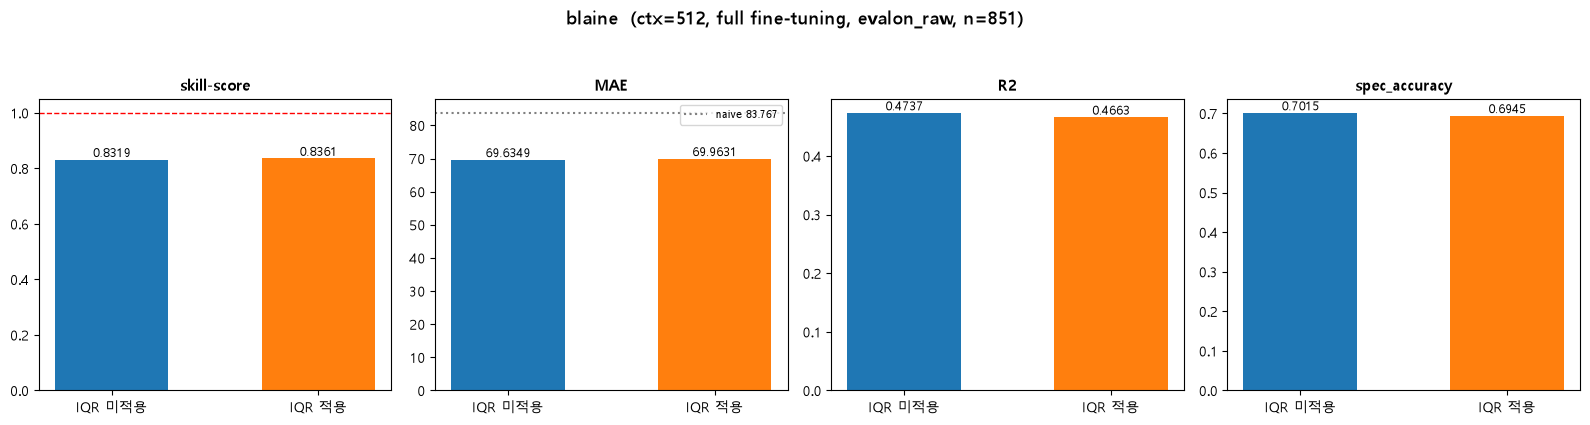

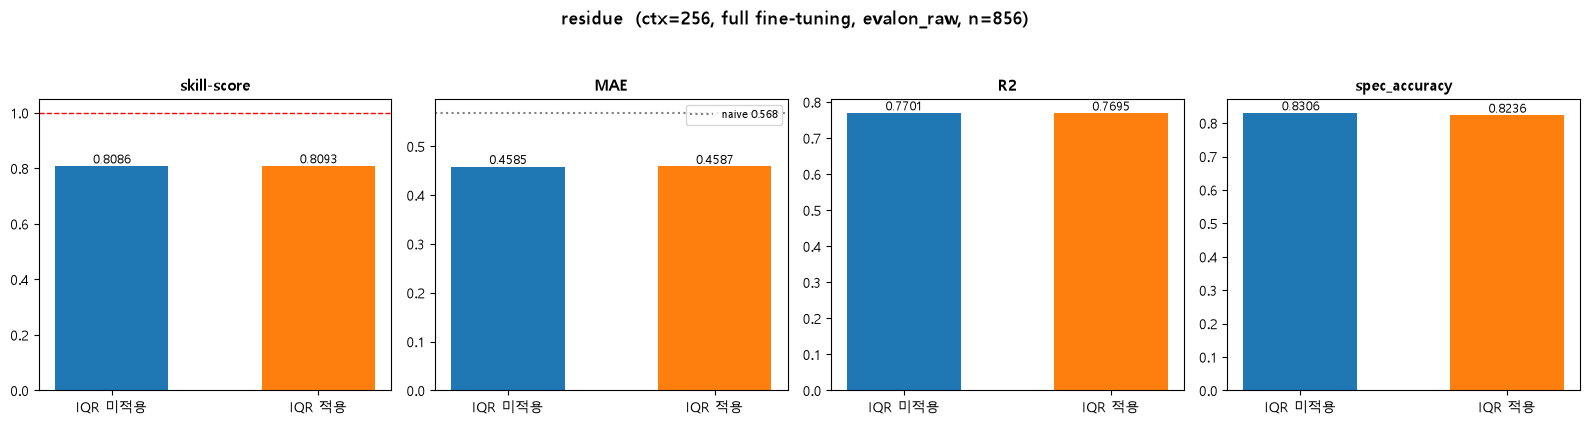

In [5]:
def plot_target(t, ev='raw'):
    d = {tv: res[(t, tv, ev)] for tv in TRAINVARS}
    m = {tv: compute_metrics(d[tv], cfg.SPEC_RANGES[t]) for tv in TRAINVARS}
    sk = {tv: normalized_skill_score(d[tv]) for tv in TRAINVARS}
    nmae = float(np.abs(d['withoutiqr']['actual'] - d['withoutiqr']['naive_pred']).mean())
    panels = [('skill-score', sk, None), ('MAE', {k: m[k]['MAE'] for k in TRAINVARS}, nmae),
              ('R2', {k: m[k]['R2'] for k in TRAINVARS}, None),
              ('spec_accuracy', {k: m[k]['spec_accuracy'] for k in TRAINVARS}, None)]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'{t}  (ctx={CTX[t]}, full fine-tuning, evalon_{ev}, n={len(d["withoutiqr"])})',
                 fontsize=13, fontweight='bold', y=1.05)
    for ax, (name, vals, naive) in zip(axes, panels):
        xs = np.arange(len(TRAINVARS))
        bars = ax.bar(xs, [vals[tv] for tv in TRAINVARS], color=[COLOR[tv] for tv in TRAINVARS], width=0.55)
        for bb, tv in zip(bars, TRAINVARS):
            ax.text(bb.get_x() + bb.get_width() / 2, bb.get_height(), f'{vals[tv]:.4f}',
                    ha='center', va='bottom', fontsize=9)
        if naive is not None:
            ax.axhline(naive, color='grey', ls=':', label=f'naive {naive:.3f}'); ax.legend(fontsize=8)
        if name == 'skill-score':
            ax.axhline(1.0, color='red', ls='--', lw=1)
        ax.set_xticks(xs); ax.set_xticklabels([TRAIN_LABEL[tv] for tv in TRAINVARS])
        ax.set_title(name, fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

for t in cfg.TARGET_COLS:
    plot_target(t, 'raw')


## 5. 결론

_아래는 build 스크립트 하드코딩 요약 — 숫자는 위 셀에서 재확인._

In [6]:
for t in cfg.TARGET_COLS:
    print(f'--- {t} (ctx={CTX[t]}) ---')
    for ev in EVALVARS:
        a, b = res[(t, 'withoutiqr', ev)], res[(t, 'withiqr', ev)]
        sa, sb = normalized_skill_score(a), normalized_skill_score(b)
        ma, mb = compute_metrics(a, cfg.SPEC_RANGES[t])['MAE'], compute_metrics(b, cfg.SPEC_RANGES[t])['MAE']
        win = 'IQR 미적용' if sa < sb else 'IQR 적용'
        print(f'  evalon_{ev:5s}: withoutiqr skill={sa:.4f} MAE={ma:.4f} | withiqr skill={sb:.4f} MAE={mb:.4f}  -> {win} 우세')
    print()


--- blaine (ctx=512) ---
  evalon_raw  : withoutiqr skill=0.8319 MAE=69.6349 | withiqr skill=0.8361 MAE=69.9631  -> IQR 미적용 우세
  evalon_clean: withoutiqr skill=0.8652 MAE=69.2609 | withiqr skill=0.8715 MAE=69.7572  -> IQR 미적용 우세

--- residue (ctx=256) ---
  evalon_raw  : withoutiqr skill=0.8086 MAE=0.4585 | withiqr skill=0.8093 MAE=0.4587  -> IQR 미적용 우세
  evalon_clean: withoutiqr skill=0.8723 MAE=0.4145 | withiqr skill=0.8749 MAE=0.4160  -> IQR 미적용 우세



<!-- 결론 텍스트는 EXPERIMENT_LOG.md 참조 -->